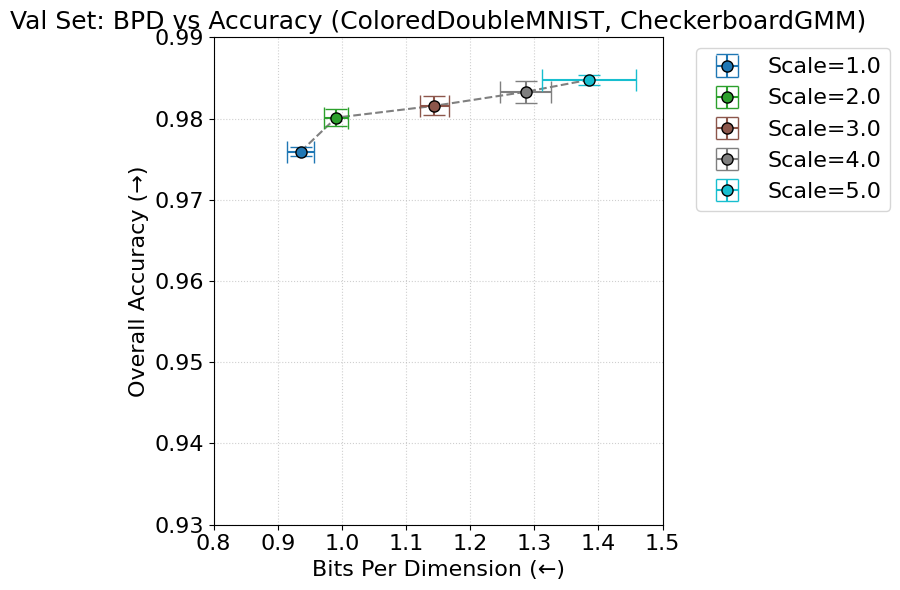

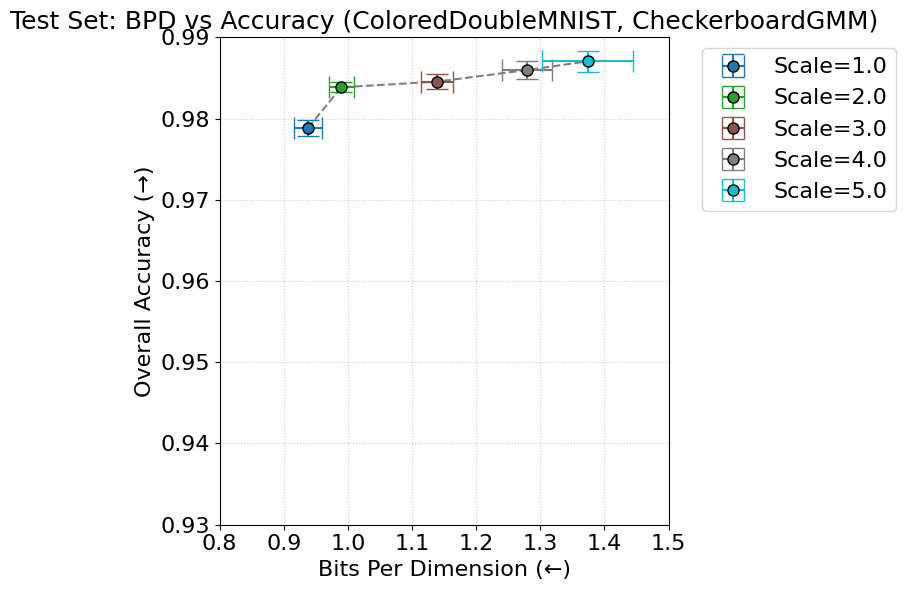

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

prior = "CheckerboardGMM"
csv_path = f"csv/evaluation_results_CheckerboardGMM_4_attr_vary_scale.csv"

def calculate_pareto_mask(df, bpd_mean, bpd_ci, acc_mean, acc_ci, method="robust"):
    if method == "robust":
        q_bpd = (df[bpd_mean] + df[bpd_ci]).values[:, np.newaxis]
        q_acc = (df[acc_mean] - df[acc_ci]).values[:, np.newaxis]
        
        p_bpd = (df[bpd_mean] - df[bpd_ci]).values[np.newaxis, :]
        p_acc = (df[acc_mean] + df[acc_ci]).values[np.newaxis, :]
    else:
        q_bpd = df[bpd_mean].values[:, np.newaxis]
        q_acc = df[acc_mean].values[:, np.newaxis]
        
        p_bpd = df[bpd_mean].values[np.newaxis, :]
        p_acc = df[acc_mean].values[np.newaxis, :]

    dominates = (q_bpd < p_bpd) & (q_acc > p_acc)
    return ~np.any(dominates, axis=0)

def plot_pareto_split(df, split_name, method="robust"):
    bpd_m, bpd_c = f"{split_name}_bpd_mean", f"{split_name}_bpd_ci"
    acc_m, acc_c = f"{split_name}_acc_mean", f"{split_name}_acc_ci"

    df['is_pareto'] = calculate_pareto_mask(df, bpd_m, bpd_c, acc_m, acc_c, method)
    pareto_df = df[df['is_pareto']].sort_values(by=bpd_m)
    non_pareto = df[~df['is_pareto']]

    plt.figure(figsize=(8, 6))

    plt.errorbar(
        x=non_pareto[bpd_m], y=non_pareto[acc_m], 
        xerr=non_pareto[bpd_c], yerr=non_pareto[acc_c], 
        fmt='none', color='lightgray', ecolor='lightgray', capsize=5, zorder=1
    )

    colors = plt.cm.tab10(np.linspace(0, 1, len(pareto_df)))
    
    for (idx, row), color in zip(pareto_df.iterrows(), colors):
        # label_parts = [f"{row.get('MODEL', 'Model')}"]
        label_parts = []
        if 'SCALE' in row and pd.notna(row['SCALE']): label_parts.append(f"Scale={row['SCALE']}")
        if 'BETA' in row and pd.notna(row['BETA']): label_parts.append(f"Beta={row['BETA']}")
        # if 'VERSION' in row and pd.notna(row['VERSION']): label_parts.append(f"V={row['VERSION']}")
        
        plt.errorbar(
            x=row[bpd_m], y=row[acc_m], 
            xerr=row[bpd_c], yerr=row[acc_c],
            fmt='o', color=color, ecolor=color, 
            capsize=8, markeredgecolor='black', markersize=8,
            label=" | ".join(label_parts), zorder=5
        )

    plt.plot(pareto_df[bpd_m], pareto_df[acc_m], '--', color='gray', zorder=4)

    plt.title(f'{split_name.capitalize()} Set: BPD vs Accuracy (ColoredDoubleMNIST, {prior})', fontsize=18)
    plt.xlabel('Bits Per Dimension (←)', fontsize=16)
    plt.ylabel('Overall Accuracy (→)', fontsize=16)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim(0.93,0.99)
    plt.xlim(0.8,1.5)
    plt.tight_layout()
    plt.show()

def generate_pareto_plots(csv_file, method="robust"):
    df = pd.read_csv(csv_file)
    
    if 'TYPE' in df.columns:
        df = df[df['TYPE'] == 'best_loss']

    total_dim = 3 * 28 * 56
    
    for split in ['val', 'test']:
        df[f'{split}_bpd_mean'] = df[f'{split}_loss_mean'] / (math.log(2) * total_dim) + 8
        df[f'{split}_bpd_ci'] = df[f'{split}_loss_ci'] / (math.log(2) * total_dim)
        
        plot_pareto_split(df.copy(), split, method)

# Execution
generate_pareto_plots(csv_path, method="robust")

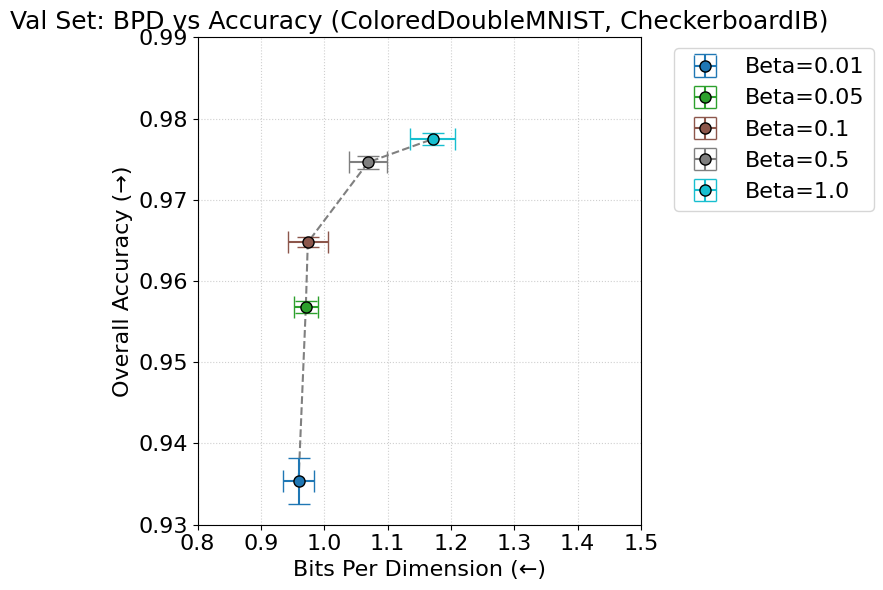

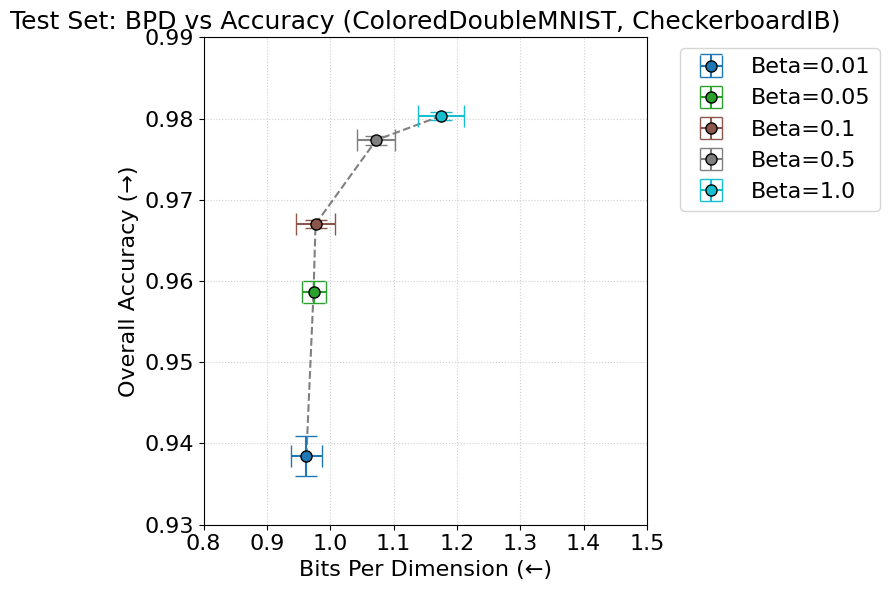

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

prior = "CheckerboardIB"
csv_path = f"csv/evaluation_results_CheckerboardIB_4_attr_scale_0.0_vary_beta.csv"

def calculate_pareto_mask(df, bpd_mean, bpd_ci, acc_mean, acc_ci, method="robust"):
    if method == "robust":
        q_bpd = (df[bpd_mean] + df[bpd_ci]).values[:, np.newaxis]
        q_acc = (df[acc_mean] - df[acc_ci]).values[:, np.newaxis]
        
        p_bpd = (df[bpd_mean] - df[bpd_ci]).values[np.newaxis, :]
        p_acc = (df[acc_mean] + df[acc_ci]).values[np.newaxis, :]
    else:
        q_bpd = df[bpd_mean].values[:, np.newaxis]
        q_acc = df[acc_mean].values[:, np.newaxis]
        
        p_bpd = df[bpd_mean].values[np.newaxis, :]
        p_acc = df[acc_mean].values[np.newaxis, :]

    dominates = (q_bpd < p_bpd) & (q_acc > p_acc)
    return ~np.any(dominates, axis=0)

def plot_pareto_split(df, split_name, method="robust"):
    bpd_m, bpd_c = f"{split_name}_bpd_mean", f"{split_name}_bpd_ci"
    acc_m, acc_c = f"{split_name}_acc_mean", f"{split_name}_acc_ci"

    df['is_pareto'] = calculate_pareto_mask(df, bpd_m, bpd_c, acc_m, acc_c, method)
    pareto_df = df[df['is_pareto']].sort_values(by=bpd_m)
    non_pareto = df[~df['is_pareto']]

    plt.figure(figsize=(8, 6))

    plt.errorbar(
        x=non_pareto[bpd_m], y=non_pareto[acc_m], 
        xerr=non_pareto[bpd_c], yerr=non_pareto[acc_c], 
        fmt='none', color='lightgray', ecolor='lightgray', capsize=5, zorder=1
    )

    colors = plt.cm.tab10(np.linspace(0, 1, len(pareto_df)))
    
    for (idx, row), color in zip(pareto_df.iterrows(), colors):
        # label_parts = [f"{row.get('MODEL', 'Model')}"]
        label_parts = []
        if 'BETA' in row and pd.notna(row['BETA']): label_parts.append(f"Beta={row['BETA']}")
        # if 'VERSION' in row and pd.notna(row['VERSION']): label_parts.append(f"V={row['VERSION']}")
        
        plt.errorbar(
            x=row[bpd_m], y=row[acc_m], 
            xerr=row[bpd_c], yerr=row[acc_c],
            fmt='o', color=color, ecolor=color, 
            capsize=8, markeredgecolor='black', markersize=8,
            label=" | ".join(label_parts), zorder=5
        )

    plt.plot(pareto_df[bpd_m], pareto_df[acc_m], '--', color='gray', zorder=4)

    plt.title(f'{split_name.capitalize()} Set: BPD vs Accuracy (ColoredDoubleMNIST, {prior})', fontsize=18)
    plt.xlabel('Bits Per Dimension (←)', fontsize=16)
    plt.ylabel('Overall Accuracy (→)', fontsize=16)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim(0.93,0.99)
    plt.xlim(0.8,1.5)
    plt.tight_layout()
    plt.show()

def generate_pareto_plots(csv_file, method="robust"):
    df = pd.read_csv(csv_file)
    
    if 'TYPE' in df.columns:
        df = df[df['TYPE'] == 'best_loss']

    total_dim = 3 * 28 * 56
    
    for split in ['val', 'test']:
        df[f'{split}_bpd_mean'] = (df[f'{split}_gen_loss_mean'] + 0.5 * math.log(2 * np.pi)) / math.log(2) + 8
        df[f'{split}_bpd_ci'] = df[f'{split}_gen_loss_ci'] / math.log(2)
        
        plot_pareto_split(df.copy(), split, method)

# Execution
generate_pareto_plots(csv_path, method="robust")

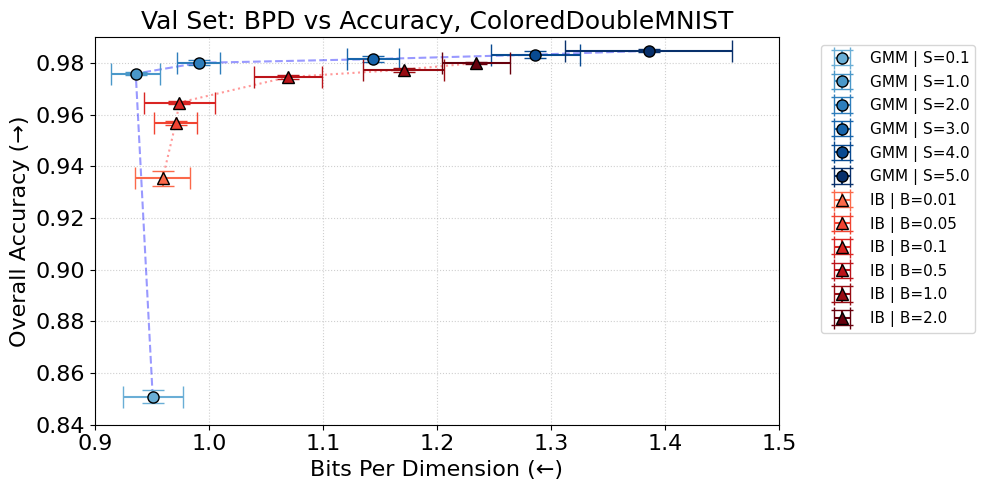

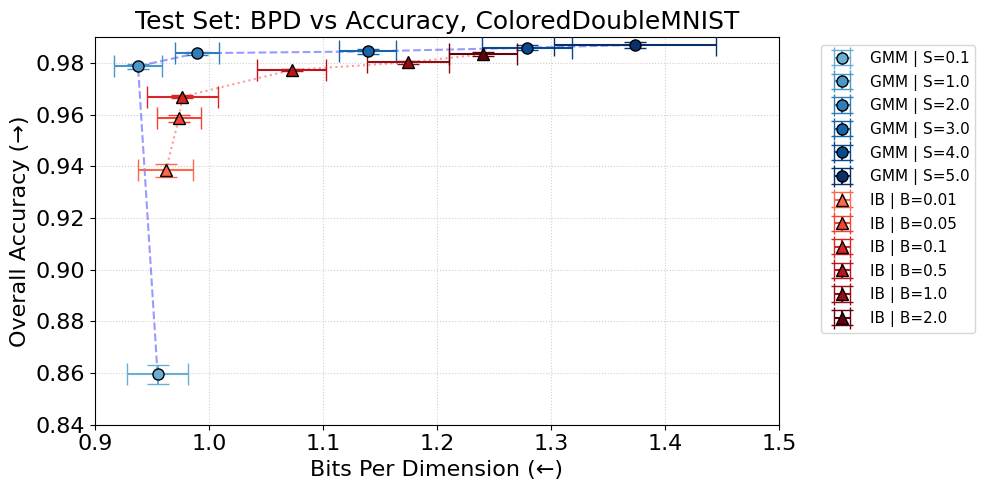

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# File paths
csv_path_gmm = "csv/evaluation_results_CheckerboardGMM_4_attr_vary_scale.csv"
csv_path_ib = "csv/evaluation_results_CheckerboardIB_4_attr_scale_0.0_vary_beta.csv"

def calculate_pareto_mask(df, bpd_mean, bpd_ci, acc_mean, acc_ci, method="robust"):
    if df.empty:
        return np.array([], dtype=bool)
        
    if method == "robust":
        q_bpd = (df[bpd_mean] + df[bpd_ci]).values[:, np.newaxis]
        q_acc = (df[acc_mean] - df[acc_ci]).values[:, np.newaxis]
        
        p_bpd = (df[bpd_mean] - df[bpd_ci]).values[np.newaxis, :]
        p_acc = (df[acc_mean] + df[acc_ci]).values[np.newaxis, :]
    else:
        q_bpd = df[bpd_mean].values[:, np.newaxis]
        q_acc = df[acc_mean].values[:, np.newaxis]
        
        p_bpd = df[bpd_mean].values[np.newaxis, :]
        p_acc = df[acc_mean].values[np.newaxis, :]

    dominates = (q_bpd < p_bpd) & (q_acc > p_acc)
    return ~np.any(dominates, axis=0)

def load_and_prep_data(csv_file, model_type):
    df = pd.read_csv(csv_file)
    if 'TYPE' in df.columns:
        df = df[df['TYPE'] == 'best_loss']

    total_dim = 3 * 28 * 56
    
    # Calculate BPD based on the specific math for each model
    for split in ['val', 'test']:
        if model_type == 'GMM':
            df[f'{split}_bpd_mean'] = df[f'{split}_loss_mean'] / (math.log(2) * total_dim) + 8
            df[f'{split}_bpd_ci'] = df[f'{split}_loss_ci'] / (math.log(2) * total_dim)
        elif model_type == 'IB':
            df[f'{split}_bpd_mean'] = (df[f'{split}_gen_loss_mean'] + 0.5 * math.log(2 * np.pi)) / math.log(2) + 8
            df[f'{split}_bpd_ci'] = df[f'{split}_gen_loss_ci'] / math.log(2)
            
    df['MODEL_TYPE'] = model_type
    return df

def plot_unified_split(df_gmm, df_ib, split_name, method="robust"):
    bpd_m, bpd_c = f"{split_name}_bpd_mean", f"{split_name}_bpd_ci"
    acc_m, acc_c = f"{split_name}_acc_mean", f"{split_name}_acc_ci"

    # Calculate Pareto masks independently for both models
    df_gmm['is_pareto'] = calculate_pareto_mask(df_gmm, bpd_m, bpd_c, acc_m, acc_c, method)
    df_ib['is_pareto'] = calculate_pareto_mask(df_ib, bpd_m, bpd_c, acc_m, acc_c, method)

    pareto_gmm = df_gmm[df_gmm['is_pareto']].sort_values(by=acc_m)
    non_pareto_gmm = df_gmm[~df_gmm['is_pareto']]

    pareto_ib = df_ib[df_ib['is_pareto']].sort_values(by=bpd_m)
    non_pareto_ib = df_ib[~df_ib['is_pareto']]

    plt.figure(figsize=(10, 5)) # Slightly wider to accommodate a larger legend

    # 1. Plot Non-Pareto Points (Background)
    if not non_pareto_gmm.empty:
        plt.errorbar(
            x=non_pareto_gmm[bpd_m], y=non_pareto_gmm[acc_m], 
            xerr=non_pareto_gmm[bpd_c], yerr=non_pareto_gmm[acc_c], 
            fmt='o', color='lightgray', ecolor='lightgray', capsize=4, zorder=1, label='Non-Pareto GMM'
        )
    if not non_pareto_ib.empty:
        plt.errorbar(
            x=non_pareto_ib[bpd_m], y=non_pareto_ib[acc_m], 
            xerr=non_pareto_ib[bpd_c], yerr=non_pareto_ib[acc_c], 
            fmt='^', color='lightgray', ecolor='lightgray', capsize=4, zorder=1, label='Non-Pareto IB'
        )

    # 2. Plot GMM Pareto Points (Blues, Circles)
    colors_gmm = plt.cm.Blues(np.linspace(0.5, 1, max(1, len(pareto_gmm))))
    for (idx, row), color in zip(pareto_gmm.iterrows(), colors_gmm):
        label_parts = ["GMM"]
        if 'SCALE' in row and pd.notna(row['SCALE']): label_parts.append(f"S={row['SCALE']}")
        if 'BETA' in row and pd.notna(row['BETA']): label_parts.append(f"B={row['BETA']}")
        
        plt.errorbar(
            x=row[bpd_m], y=row[acc_m], xerr=row[bpd_c], yerr=row[acc_c],
            fmt='o', color=color, ecolor=color, 
            capsize=8, markeredgecolor='black', markersize=8,
            label=" | ".join(label_parts), zorder=5
        )

    # 3. Plot IB Pareto Points (Reds, Triangles)
    colors_ib = plt.cm.Reds(np.linspace(0.5, 1, max(1, len(pareto_ib))))
    for (idx, row), color in zip(pareto_ib.iterrows(), colors_ib):
        label_parts = ["IB"]
        if 'BETA' in row and pd.notna(row['BETA']): label_parts.append(f"B={row['BETA']}")
        
        plt.errorbar(
            x=row[bpd_m], y=row[acc_m], xerr=row[bpd_c], yerr=row[acc_c],
            fmt='^', color=color, ecolor=color, 
            capsize=8, markeredgecolor='black', markersize=9, # slightly larger marker for triangles
            label=" | ".join(label_parts), zorder=5
        )

    # 4. Connect the fronts with distinct lines
    if not pareto_gmm.empty:
        plt.plot(pareto_gmm[bpd_m], pareto_gmm[acc_m], '--', color='blue', alpha=0.4, zorder=4)
    if not pareto_ib.empty:
        plt.plot(pareto_ib[bpd_m], pareto_ib[acc_m], ':', color='red', alpha=0.4, zorder=4)

    plt.title(f'{split_name.capitalize()} Set: BPD vs Accuracy, ColoredDoubleMNIST', fontsize=18)
    plt.xlabel('Bits Per Dimension (←)', fontsize=16)
    plt.ylabel('Overall Accuracy (→)', fontsize=16)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Render deduplicated legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), fontsize=11, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim(0.84, 0.99)
    plt.xlim(0.9, 1.5)
    plt.tight_layout()
    plt.show()

def generate_unified_plots(csv_gmm, csv_ib, method="robust"):
    df_gmm = load_and_prep_data(csv_gmm, model_type='GMM')
    df_ib = load_and_prep_data(csv_ib, model_type='IB')
    
    for split in ['val', 'test']:
        plot_unified_split(df_gmm.copy(), df_ib.copy(), split, method)

# Execution
generate_unified_plots(csv_path_gmm, csv_path_ib, method="robust")